In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)

df = pd.read_csv("https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/telecom_churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [2]:
df["Churn"] = df["Churn"].astype("int64")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [4]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
count,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00,3333.00
mean,101.06,437.18,8.10,179.78,100.44,30.56,200.98,100.11,17.08,200.87,100.11,9.04,10.24,4.48,2.76,1.56,0.14
std,39.82,42.37,13.69,54.47,20.07,9.26,50.71,19.92,4.31,50.57,19.57,2.28,2.79,2.46,0.75,1.32,0.35
min,1.00,408.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,23.20,33.00,1.04,0.00,0.00,0.00,0.00,0.00
25%,74.00,408.00,0.00,143.70,87.00,24.43,166.60,87.00,14.16,167.00,87.00,7.52,8.50,3.00,2.30,1.00,0.00
50%,101.00,415.00,0.00,179.40,101.00,30.50,201.40,100.00,17.12,201.20,100.00,9.05,10.30,4.00,2.78,1.00,0.00
75%,127.00,510.00,20.00,216.40,114.00,36.79,235.30,114.00,20.00,235.30,113.00,10.59,12.10,6.00,3.27,2.00,0.00
max,243.00,510.00,51.00,350.80,165.00,59.64,363.70,170.00,30.91,395.00,175.00,17.77,20.00,20.00,5.40,9.00,1.00


- In order to see statistics on non-numerical features, one has to explicitly indicate data types of interest in the include parameter.

In [5]:
df.describe(include=["object", "bool"])

,State,International plan,Voice mail plan
count,3333,3333,3333
unique,51,2,2
top,WV,No,No
freq,106,3010,2411


In [6]:
df["Area code"].value_counts()

Area code
415    1655
510     840
408     838
Name: count, dtype: int64

In [7]:
print(f"{df["Churn"].mean()*100 : .2f}")

 14.49


- 14.5% is actually quite bad for a company; such a churn rate can make the company go bankrupt.

- What are the average values of numerical features for churned users?

In [8]:
df.select_dtypes(include=["int64", "float64"])[df["Churn"]==1].mean()

Account length            102.66
Area code                 437.82
Number vmail messages       5.12
Total day minutes         206.91
Total day calls           101.34
Total day charge           35.18
Total eve minutes         212.41
Total eve calls           100.56
Total eve charge           18.05
Total night minutes       205.23
Total night calls         100.40
Total night charge          9.24
Total intl minutes         10.70
Total intl calls            4.16
Total intl charge           2.89
Customer service calls      2.23
Churn                       1.00
dtype: float64

- How much time (on average) do churned users spend on the phone during daytime?

In [9]:
df[df["Churn"]==1]["Total day minutes"].mean()

np.float64(206.91407867494823)

- How churn rates are related to International plan feature

In [10]:
pd.crosstab(df["Churn"], df["International plan"], margins=True)


International plan,No,Yes,All
Churn,,,
0,2664,186,2850
1,346,137,483
All,3010,323,3333


In [11]:
d = {"Yes":True, "No":False}
df["International plan"] = df["International plan"].map(d)

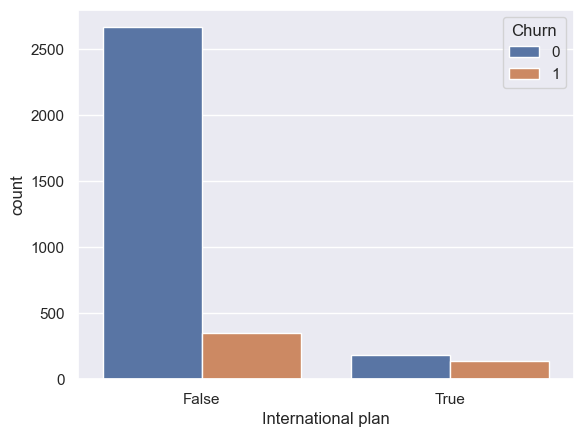

In [12]:
sns.set()
sns.countplot(x="International plan", hue="Churn", data=df);

- **Group 1**: Customers WITHOUT the International Plan
  2,700 customers stay
  300 customers leave
  Only a small portion leaves

- **Group 2**: Customers WITH the International Plan
  200 customers stay
  150 customers leave
  Almost as many leave as stay

*Why might this happen?*

- International calls might be too expensive
- Customers might be surprised by large bills
- The plan may be confusing or feels unfair

Churn                      0    1   All
Customer service calls                 
0                        605   92   697
1                       1059  122  1181
2                        672   87   759
3                        385   44   429
4                         90   76   166
5                         26   40    66
6                          8   14    22
7                          4    5     9
8                          1    1     2
9                          0    2     2
All                     2850  483  3333


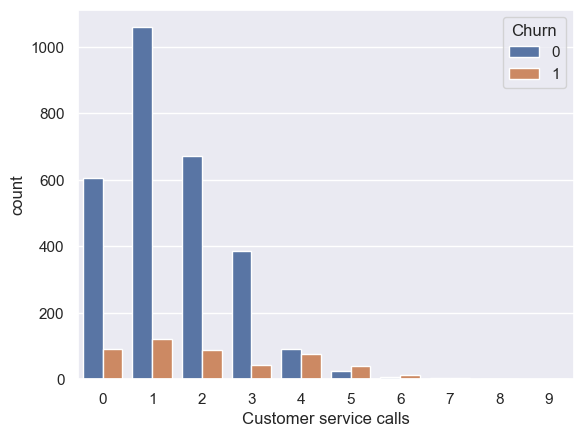

In [24]:
print(pd.crosstab(df["Customer service calls"],df["Churn"], margins=True))
sns.countplot(data=df, x="Customer service calls", hue="Churn")
plt.show()

It is clear from the above plot that the churning rate has started increasing from 4 or more customer service calls.

Now lets add a binary feature to data frame to check whether more number of service calls are churning or not.


In [29]:
df["Many service calls"] = df["Customer service calls"] > 3

It is clear from the above analysis that both International plan and number of service calls affects the churning rate
Now lets check what happens to customers with both many service call and International plan

Churn,0,1,All
row_0,,,
False,2841,464,3305
True,9,19,28
All,2850,483,3333


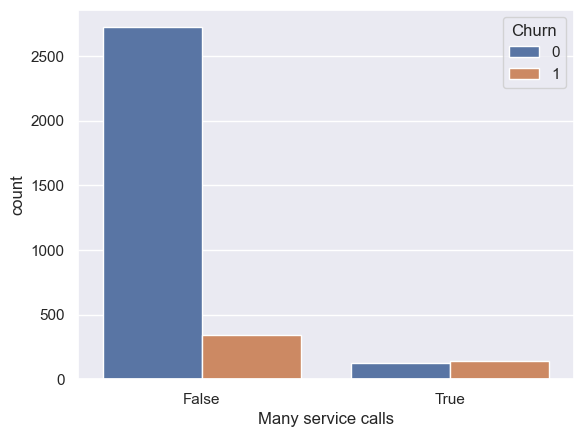

In [30]:
sns.countplot(data=df, x="Many service calls", hue="Churn")
pd.crosstab((df["Many_service calls"]) & (df["International plan"]), df["Churn"], margins=True)

Thus, by predicting that a customer will not remain loyal (Churn=1) if they have made more than 3 calls to the service center AND have added the International Plan, and predicting Churn=0 otherwise (and “otherwise” here means negation, i.e. Many_service_calls <= 3 OR International Plan is not added ), we anticipate an accuracy of 85.8% 

(we will only be incorrect 464 + 9 times, look at the contingency table above; and 
 $$
\frac{464+9}{3333} \approx {85.8}\%
$$

 ). 

This 85.8% accuracy, obtained through such straightforward reasoning, serves as a useful starting point (baseline) for the development of future machine learning models.